# GTEx tissue feature importance analysis (K-means binary + SHAP)

1. Load GTEx LV data, tissue metadata, and the saved K-means model
2. Derive binary tissue labels from K-means cluster assignments (majority-vote tissue per cluster)
3. For each tissue, train a binary RF classifier (tissue vs. rest) using k-means-derived labels
4. Compute SHAP values to explain which LVs drive each tissue
5. Downstream: specificity heatmap, trait associations, GO BP pathways

💡 **Environment:** `clamp-analyses`

In [1]:
import os
import pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns

from pyprojroot.here import here
import shap

import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
readRDS = ro.r["readRDS"]

import csv
import re
import textwrap
import urllib.request
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from itertools import groupby

np.random.seed(42)

/home/msubirana/miniconda3/envs/clamp-analyses/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Settings

In [2]:
GLOBAL_SEED = 42
N_TOP_FEATURES = 10
CORRELATION_THRESHOLD = 0.8

# random forest hyperparameter grid
PARAM_GRID = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
}

# Output

In [3]:
OUTPUT_DIR = here('output/gtex_feature_importance_kmeans_binary_shap')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")

Output directory: /home/msubirana/Documents/pivlab/clamp-analyses/output/gtex_feature_importance_kmeans_binary_shap


# Load data

In [4]:
# load .rds files from CLAMP with different priors
gtex_GO_BP_CLAMP_rds = readRDS(str(here('output/gtex/gtex_C2CP_CLAMP.rds')))


def extract_B_matrix(rds_obj):
    B_matrix = rds_obj.rx2("B")
    with localconverter(ro.default_converter + pandas2ri.converter):
        B_values = ro.conversion.rpy2py(B_matrix)
    df = pd.DataFrame(
        data=B_values,
        index=B_matrix.rownames if B_matrix.rownames else None,
        columns=B_matrix.colnames if B_matrix.colnames else None,
    )
    return df

gtex_GO_BP_CLAMP = extract_B_matrix(gtex_GO_BP_CLAMP_rds)

lv_data = gtex_GO_BP_CLAMP
lv_data.head()

,GTEX-1117F-0226-SM-5GZZ7,GTEX-1117F-0426-SM-5EGHI,GTEX-1117F-0526-SM-5EGHJ,GTEX-1117F-0626-SM-5N9CS,GTEX-1117F-0726-SM-5GIEN,GTEX-1117F-1326-SM-5EGHH,GTEX-1117F-2426-SM-5EGGH,GTEX-1117F-2526-SM-5GZY6,GTEX-1117F-2826-SM-5GZXL,GTEX-1117F-2926-SM-5GZYI,...,GTEX-ZZPU-1126-SM-5N9CW,GTEX-ZZPU-1226-SM-5N9CK,GTEX-ZZPU-1326-SM-5GZWS,GTEX-ZZPU-1426-SM-5GZZ6,GTEX-ZZPU-1826-SM-5E43L,GTEX-ZZPU-2126-SM-5EGIU,GTEX-ZZPU-2226-SM-5EGIV,GTEX-ZZPU-2426-SM-5E44I,GTEX-ZZPU-2626-SM-5E45Y,GTEX-ZZPU-2726-SM-5NQ8O
LV1,0.042488,0.230452,0.132334,0.105064,0.157415,0.091908,-0.130049,-0.051270,-0.009231,-0.037468,...,0.128501,0.156842,-0.004152,0.021310,0.038278,0.000041,0.007891,0.200221,0.044497,0.055179
LV2,-0.156233,-0.300193,-0.191489,-0.114533,-0.183982,-0.225151,-0.106812,-0.120164,-0.249983,-0.171804,...,-0.163594,-0.028682,-0.139288,-0.203544,-0.159509,-0.040002,-0.219097,-0.165934,-0.299518,-0.272677
LV3,-0.266451,-0.019985,-0.202227,-0.189687,0.127665,-0.265006,-0.188259,0.130413,-0.174151,0.012298,...,0.433255,0.056235,0.057290,0.172689,0.146825,-0.190567,0.162997,-0.047090,0.052670,-0.110635
LV4,0.952345,-0.124907,0.144189,0.127260,0.224577,0.165120,0.293712,-0.088033,0.279473,0.345844,...,0.147640,0.039852,0.112291,0.126342,0.004819,0.276404,-0.296886,-0.051308,-0.183508,0.283433
LV5,-0.139668,-0.000442,-0.027747,0.011711,0.074724,0.058611,-0.156349,0.460439,-0.060347,0.047107,...,0.070286,-0.017669,-0.047141,-0.007070,-0.037564,-0.145164,0.437739,-0.080496,-0.041129,-0.074026


In [5]:
def extract_summary_matrix(rds_obj):
    summary_matrix = rds_obj.rx2("summary")
    with localconverter(ro.default_converter + pandas2ri.converter):
        summary_values = ro.conversion.rpy2py(summary_matrix)
    df = pd.DataFrame(
        data=summary_values,
        index=summary_matrix.rownames if summary_matrix.rownames else None,
        columns=summary_matrix.colnames if summary_matrix.colnames else None,
    )
    return df

gtex_GO_BP_summary = extract_summary_matrix(gtex_GO_BP_CLAMP_rds)
gtex_GO_BP_summary["pathway"] = gtex_GO_BP_summary["pathway"].str.replace("C2CP_", "", regex=False)

print(gtex_GO_BP_summary.shape)
gtex_GO_BP_summary.head()

(3101, 7)


,pathway,LV,AUC,p_value,FDR,npos,nneg
C2CP231,BIOCARTA_PLATELETAPP_PATHWAY,LV1,0.918619,0.012089,0.080620,2,21510
C2CP275,BIOCARTA_SPPA_PATHWAY,LV1,0.278382,0.928101,0.943738,3,21510
C2CP1103,KEGG_MEDICUS_VARIANT_MUTATION_CAUSED_ABERRANT_...,LV1,0.867736,0.023837,0.117218,2,21510
C2CP1761,REACTOME_DISSOLUTION_OF_FIBRIN_CLOT,LV1,0.524547,0.447441,0.680487,2,21510
C2CP2256,REACTOME_MITOCHONDRIAL_FATTY_ACID_BETA_OXIDATI...,LV1,0.848489,0.030285,0.136502,2,21510


In [6]:
path = here('data/gtex/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt')

gtex_meta = pd.read_csv(
    path,
    sep='\t',
    header=0,
    dtype=str,
    quoting=csv.QUOTE_NONE,
    engine='python',
    comment=None,
    keep_default_na=False,
    on_bad_lines='warn'
)

print(gtex_meta.shape)
gtex_meta.head()

(22951, 63)


,SAMPID,SMATSSCR,SMCENTER,SMPTHNTS,SMRIN,SMTS,SMTSD,SMUBRID,SMTSISCH,SMTSPAX,...,SME1ANTI,SMSPLTRD,SMBSMMRT,SME1SNSE,SME1PCTS,SMRRNART,SME1MPRT,SMNUM5CD,SMDPMPRT,SME2PCTS
0,GTEX-1117F-0003-SM-58Q7G,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
1,GTEX-1117F-0003-SM-5DWSB,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
2,GTEX-1117F-0003-SM-6WBT7,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
3,GTEX-1117F-0011-R10a-SM-AHZ7F,,"B1, A1",,,Brain,Brain - Frontal Cortex (BA9),0009834,1193,,...,,,,,,,,,,
4,GTEX-1117F-0011-R10b-SM-CYKQ8,,"B1, A1",,7.2,Brain,Brain - Frontal Cortex (BA9),0009834,1193,,...,,,,,,,,,,


In [7]:
# transpose to get samples as rows, LVs as columns
lv_matrix = lv_data.T

# filter metadata to only include samples in LV matrix
meta_filtered = gtex_meta[gtex_meta['SAMPID'].isin(lv_matrix.index)].copy()
meta_filtered = meta_filtered.set_index('SAMPID')
meta_filtered = meta_filtered.loc[lv_matrix.index]

tissue_labels = meta_filtered['SMTS']

print(f"Number of samples: {len(lv_matrix)}")
print(f"Number of LVs: {lv_matrix.shape[1]}")
print(f"Number of unique tissues: {tissue_labels.nunique()}")
print(f"\nTissue distribution:")
print(tissue_labels.value_counts().head())

Number of samples: 17382
Number of LVs: 412
Number of unique tissues: 30

Tissue distribution:
SMTS
Brain             2642
Skin              1809
Esophagus         1445
Blood Vessel      1335
Adipose Tissue    1204
Name: count, dtype: int64


In [8]:
phenoplier_path = here('data/gtex/phenoplier/gtex-gls-summary-phenomexcan.tsv.gz')

phenoplier = pd.read_csv(
    phenoplier_path,
    sep="\t",
    compression="gzip",
    low_memory=False
)

print(phenoplier.shape)
print(phenoplier.columns.tolist())

(1668188, 5)
['phenotype', 'phenotype_desc', 'lv', 'pvalue', 'fdr']


# Load K-means model

Load the K-means model trained in `00_kmeans_clustering.ipynb` (CLAMP BP only).
Cluster labels are used to derive binary tissue labels for each RF.

In [9]:
model_path = here('output/gtex/kmeans_models/gtex_GO_BP_CLAMP_kmeans_model.pkl')

with open(model_path, 'rb') as f:
    model_bundle = pickle.load(f)

km_model = model_bundle['model']
km_scaler = model_bundle['scaler']
best_k = model_bundle['best_k']
best_approach = model_bundle['best_approach']
saved_ari = model_bundle['ari']

print(f"K-means model: k={best_k}, approach={best_approach}, ARI={saved_ari:.4f}")

# apply the same preprocessing and get cluster assignments
if best_approach == 'scaled':
    X_km = km_scaler.transform(lv_matrix.astype(np.float32))
else:
    X_km = lv_matrix.values.astype(np.float32)

cluster_labels = km_model.predict(X_km)

# verify ARI matches
reproduced_ari = adjusted_rand_score(tissue_labels.values, cluster_labels)
print(f"Reproduced ARI: {reproduced_ari:.4f} (saved: {saved_ari:.4f})")

# map clusters to tissues (majority vote)
cluster_tissue_map = {}
cluster_tissue_purity = {}

for c in range(best_k):
    mask = cluster_labels == c
    cluster_tissues = tissue_labels[mask]
    dominant_tissue = cluster_tissues.value_counts().index[0]
    purity = cluster_tissues.value_counts().iloc[0] / len(cluster_tissues)
    cluster_tissue_map[c] = dominant_tissue
    cluster_tissue_purity[c] = purity

# group clusters by dominant tissue
tissue_to_clusters = defaultdict(list)
for c, tissue in cluster_tissue_map.items():
    tissue_to_clusters[tissue].append(c)

# cluster summary
cluster_summary = pd.DataFrame({
    'Cluster': range(best_k),
    'Dominant_Tissue': [cluster_tissue_map[c] for c in range(best_k)],
    'Purity': [cluster_tissue_purity[c] for c in range(best_k)],
    'Size': [np.sum(cluster_labels == c) for c in range(best_k)]
}).sort_values('Dominant_Tissue')

print(f"\nCluster summary ({best_k} clusters):")
display(cluster_summary)

# binary tissue labels derived from k-means (positive = sample in a cluster dominated by that tissue)
km_tissue_labels = pd.Series(
    [cluster_tissue_map[c] for c in cluster_labels],
    index=lv_matrix.index
)
print(f"\nK-means-derived tissue label distribution:")
print(km_tissue_labels.value_counts())

K-means model: k=20, approach=scaled, ARI=0.7037
Reproduced ARI: 0.7025 (saved: 0.7037)

Cluster summary (20 clusters):


,Cluster,Dominant_Tissue,Purity,Size
9,9,Adipose Tissue,0.765006,1566
17,17,Blood,1.000000,174
11,11,Blood,1.000000,755
16,16,Blood Vessel,0.989189,1295
1,1,Brain,0.999545,2198
18,18,Brain,1.000000,442
0,0,Esophagus,0.833837,662
4,4,Esophagus,0.560897,1560
8,8,Heart,0.790248,1087
12,12,Lung,0.998267,577



K-means-derived tissue label distribution:
Brain             2640
Esophagus         2222
Skin              1807
Pancreas          1742
Adipose Tissue    1566
Blood Vessel      1295
Heart             1087
Blood              929
Prostate           810
Muscle             806
Thyroid            641
Nerve              622
Lung               577
Testis             361
Pituitary          277
Name: count, dtype: int64


# LV correlation analysis

Before running feature importance, we need to check for multicollinearity among LVs.
Highly correlated features can affect SHAP importance interpretation.
Pearson correlation

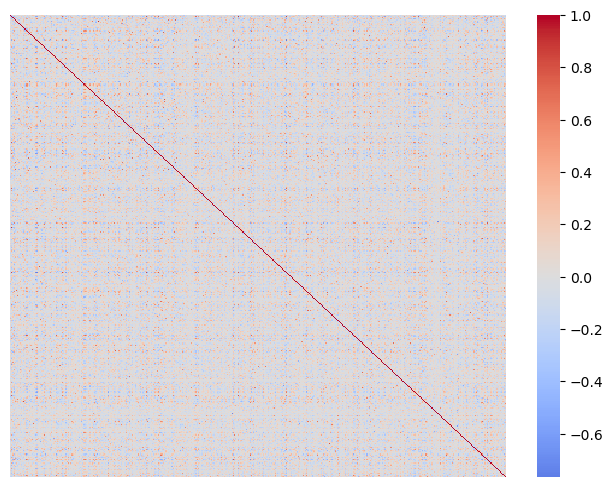

Number of highly correlated pairs (|r| > 0.9): 1


In [10]:
# correlation matrix
corr_matrix = lv_matrix.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=False)
plt.show()

# find highly correlated pairs
high_corr_threshold = 0.9
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > high_corr_threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print(f"Number of highly correlated pairs (|r| > {high_corr_threshold}): {len(high_corr_pairs)}")

LVs independent

# Feature importance analysis (K-means binary + SHAP)

For each tissue (defined by k-means cluster majority vote), train a **binary RF**:
- Positive class (1): samples assigned to clusters whose dominant tissue is this tissue
- Negative class (0): all other samples

Uses nested cross-validation:
- Outer CV: unbiased performance estimation
- Inner CV: hyperparameter tuning

In [11]:
_files_exist = (
    (OUTPUT_DIR / "accuracy_summary.tsv").exists() and
    (OUTPUT_DIR / "all_shap_positive.tsv").exists() and
    (OUTPUT_DIR / "cumulative_importance.tsv").exists()
)
if _files_exist:
    print("results found, skipping feature importance and SHAP computation")
else:
    print("results not found, running feature importance and SHAP computation")

results found, skipping feature importance and SHAP computation


In [12]:
if not _files_exist:
    global_seed = GLOBAL_SEED

    param_distributions = {
        'n_estimators': [100, 300, 500, 1000],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
    }

    tissues = sorted(tissue_to_clusters.keys())

    accuracy_list = []
    shap_results_list = []
    cumulative_importance_list = []
    top5_lvs_by_tissue = {}

    (OUTPUT_DIR / "per_tissue").mkdir(parents=True, exist_ok=True)

    for i, tissue in enumerate(tissues):
        tissue_clusters = tissue_to_clusters[tissue]
        mean_purity = np.mean([cluster_tissue_purity[c] for c in tissue_clusters])

        print(f"[{i+1}/{len(tissues)}] {tissue} (clusters={tissue_clusters}, purity={mean_purity:.2f})")

        # binary label from k-means: 1 if sample's cluster belongs to this tissue
        y_binary = (km_tissue_labels == tissue).astype(int)

        n_pos = y_binary.sum()
        n_neg = (1 - y_binary).sum()
        imbalance_ratio = n_neg / n_pos if n_pos > 0 else float('inf')

        outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=global_seed + i)
        outer_test_scores = []
        best_params_list = []

        for outer_fold, (dev_idx, test_idx) in enumerate(outer_cv.split(lv_matrix, y_binary)):
            lv_data_dev = lv_matrix.iloc[dev_idx]
            y_dev = y_binary.iloc[dev_idx]
            lv_data_test = lv_matrix.iloc[test_idx]
            y_test = y_binary.iloc[test_idx]

            inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=global_seed + i)
            clf = RandomForestClassifier(random_state=global_seed + i, class_weight='balanced')
            random_search = RandomizedSearchCV(
                estimator=clf,
                param_distributions=param_distributions,
                n_iter=15,
                cv=inner_cv,
                scoring='balanced_accuracy',
                n_jobs=-1,
                random_state=global_seed + i
            )
            random_search.fit(lv_data_dev, y_dev)
            best_params_list.append(random_search.best_params_)

            final_model_outer = RandomForestClassifier(
                random_state=global_seed + i,
                class_weight='balanced',
                **random_search.best_params_
            )
            final_model_outer.fit(lv_data_dev, y_dev)
            y_pred = final_model_outer.predict(lv_data_test)
            outer_test_scores.append(balanced_accuracy_score(y_test, y_pred))

        best_fold_idx = np.argmax(outer_test_scores)
        final_params = best_params_list[best_fold_idx]

        print(f"  nested CV balanced accuracy: {np.mean(outer_test_scores):.4f} +/- {np.std(outer_test_scores):.4f}")

        # train final model on all data
        final_model = RandomForestClassifier(
            random_state=global_seed + i,
            class_weight='balanced',
            **final_params
        )
        final_model.fit(lv_matrix, y_binary)

        # SHAP analysis
        explainer = shap.TreeExplainer(final_model, data=lv_matrix, feature_perturbation="interventional")
        shap_explanation = explainer(lv_matrix)

        # extract SHAP values for positive class (tissue membership)
        shap_values_class1 = shap_explanation.values[..., 1]

        # average over samples that belong to this tissue's clusters
        tissue_mask = y_binary == 1
        shap_values_tissue_samples = shap_values_class1[tissue_mask]
        mean_shap_tissue = np.mean(shap_values_tissue_samples, axis=0)

        df_shap_all = pd.DataFrame({
            "Feature": lv_matrix.columns,
            "Mean_SHAP_Tissue": mean_shap_tissue
        })

        df_positive = df_shap_all[df_shap_all["Mean_SHAP_Tissue"] > 0].copy()
        df_positive = df_positive.sort_values("Mean_SHAP_Tissue", ascending=False).reset_index(drop=True)

        # cumulative importance
        n_features_needed = {}
        if len(df_positive) > 0:
            total_positive_shap = df_positive["Mean_SHAP_Tissue"].sum()
            df_positive["Cumulative_SHAP"] = df_positive["Mean_SHAP_Tissue"].cumsum()
            df_positive["Cumulative_Percent"] = (df_positive["Cumulative_SHAP"] / total_positive_shap) * 100
            df_positive["Rank"] = range(1, len(df_positive) + 1)

            for thresh in [50, 70, 80, 90, 95]:
                n_features_needed[thresh] = (df_positive["Cumulative_Percent"] >= thresh).idxmax() + 1

            df_cumulative = df_positive[["Feature", "Mean_SHAP_Tissue", "Cumulative_Percent", "Rank"]].copy()
            df_cumulative["Tissue"] = tissue
            cumulative_importance_list.append(df_cumulative)

        accuracy_list.append({
            "Tissue": tissue,
            "N_Clusters": len(tissue_clusters),
            "Mean_Purity": mean_purity,
            "Best_Test_Balanced_Accuracy": outer_test_scores[best_fold_idx],
            "Mean_CV_Accuracy": np.mean(outer_test_scores),
            "Std_CV_Accuracy": np.std(outer_test_scores),
            "Imbalance_Ratio": imbalance_ratio,
            "N_Positive_LVs": len(df_positive),
            "LVs_for_80pct": n_features_needed.get(80),
            "LVs_for_90pct": n_features_needed.get(90),
        })

        df_all_positive = df_positive.copy()
        df_all_positive["Tissue"] = tissue
        shap_results_list.append(df_all_positive)

        safe_name = tissue.replace(' ', '_').replace('/', '_')
        df_positive.to_csv(OUTPUT_DIR / "per_tissue" / f"shap_positive_{safe_name}.tsv", sep="\t", index=False)
        top5_lvs_by_tissue[tissue] = df_positive["Feature"].head(5).tolist()
        print(f"  top LVs: {top5_lvs_by_tissue[tissue]}")

    # compile and save results
    accuracy_df = pd.DataFrame(accuracy_list)
    shap_results_df = pd.concat(shap_results_list, ignore_index=True)
    cumulative_df = pd.concat(cumulative_importance_list, ignore_index=True)

    accuracy_df.to_csv(OUTPUT_DIR / "accuracy_summary.tsv", sep="\t", index=False)
    shap_results_df.to_csv(OUTPUT_DIR / "all_shap_positive.tsv", sep="\t", index=False)
    cumulative_df.to_csv(OUTPUT_DIR / "cumulative_importance.tsv", sep="\t", index=False)
    print(f"\ndone. results saved to: {OUTPUT_DIR}")

In [13]:
accuracy_df = pd.read_csv(OUTPUT_DIR / "accuracy_summary.tsv", sep="\t")
shap_results_df = pd.read_csv(OUTPUT_DIR / "all_shap_positive.tsv", sep="\t")
cumulative_df = pd.read_csv(OUTPUT_DIR / "cumulative_importance.tsv", sep="\t")

In [14]:
accuracy_df.sort_values(by='Mean_CV_Accuracy', ascending=False)

,Tissue,N_Clusters,Mean_Purity,Best_Test_Balanced_Accuracy,Mean_CV_Accuracy,Std_CV_Accuracy,Imbalance_Ratio,N_Positive_LVs,LVs_for_80pct,LVs_for_90pct
1,Adrenal Gland,1,1.000000,1.000000,1.000000,0.000000,66.372093,396,25,48
4,Brain,2,0.999772,1.000000,0.999966,0.000068,5.584091,395,35,68
2,Blood,2,0.880928,1.000000,0.999447,0.000881,13.920172,337,44,78
9,Muscle,1,0.996278,1.000000,0.998762,0.001517,20.565757,273,30,55
13,Skin,2,0.998845,1.000000,0.998060,0.001108,8.640599,401,52,94
14,Testis,1,1.000000,1.000000,0.997222,0.005556,47.149584,342,32,55
11,Pancreas,1,1.000000,1.000000,0.996970,0.003711,51.993902,334,39,69
15,Thyroid,1,0.590702,0.997727,0.996353,0.001118,14.845032,404,51,84
10,Nerve,1,0.993559,1.000000,0.995915,0.003640,26.990338,395,33,65
8,Lung,1,0.996540,1.000000,0.995675,0.002750,29.072664,396,29,59


In [15]:
cumulative_df.head(40)

,Feature,Mean_SHAP_Tissue,Cumulative_Percent,Rank,Tissue
0,LV301,0.120819,13.346714,1,Adipose Tissue
1,LV263,0.066886,20.735498,2,Adipose Tissue
2,LV333,0.038457,24.983785,3,Adipose Tissue
3,LV230,0.035003,28.850524,4,Adipose Tissue
4,LV151,0.033472,32.548145,5,Adipose Tissue
5,LV319,0.026850,35.514207,6,Adipose Tissue
6,LV363,0.026786,38.473215,7,Adipose Tissue
7,LV386,0.026170,41.364168,8,Adipose Tissue
8,LV7,0.024915,44.116503,9,Adipose Tissue
9,LV310,0.019039,46.219667,10,Adipose Tissue


# LV tissue annotation

For each LV, take the top 1% of samples (highest B matrix values) and annotate the LV with the dominant tissue.
Then build a heatmap showing how tissue-specific the top SHAP LVs are.

In [16]:
# annotate each LV using the top 1% of samples from the B matrix
n_top = max(1, int(len(lv_matrix) * 0.01))

lv_tissue_pct = {}
lv_tissue_annotation = {}

for lv in lv_matrix.columns:
    top_idx = lv_matrix[lv].nlargest(n_top).index
    top_tissues = tissue_labels.loc[top_idx]
    pct_dist = (top_tissues.value_counts(normalize=True) * 100).to_dict()
    lv_tissue_pct[lv] = pct_dist
    lv_tissue_annotation[lv] = top_tissues.value_counts().index[0]

lv_annot_df = pd.DataFrame({
    'LV': list(lv_tissue_annotation.keys()),
    'Annotated_Tissue': list(lv_tissue_annotation.values()),
}).set_index('LV')

print(f"top 1% = {n_top} samples per LV")
print(f"\nLV annotations per tissue:")
print(lv_annot_df['Annotated_Tissue'].value_counts())
lv_annot_df.head(10)

top 1% = 173 samples per LV

LV annotations per tissue:
Annotated_Tissue
Skin               59
Brain              59
Blood              44
Blood Vessel       35
Adipose Tissue     27
Thyroid            26
Esophagus          22
Lung               17
Nerve              16
Muscle             15
Ovary              12
Heart               9
Pituitary           9
Colon               8
Testis              7
Spleen              7
Adrenal Gland       6
Liver               6
Pancreas            5
Prostate            5
Stomach             4
Uterus              4
Small Intestine     3
Breast              2
Vagina              2
Salivary Gland      2
Kidney              1
Name: count, dtype: int64


,Annotated_Tissue
LV,
LV1,Skin
LV2,Brain
LV3,Blood
LV4,Skin
LV5,Esophagus
LV6,Testis
LV7,Muscle
LV8,Skin
LV9,Lung


In [37]:
CUMULATIVE_PCT = 40

valid_tissues = accuracy_df[
    (accuracy_df['Mean_Purity'] >= 0.7) & 
    (accuracy_df['Best_Test_Balanced_Accuracy'] >= 0.95)
]['Tissue'].tolist()

tissues_ordered = sorted(valid_tissues)

results = []
for tissue in tissues_ordered:
    df_t = cumulative_df[cumulative_df['Tissue'] == tissue].sort_values('Rank')
    mask = df_t['Cumulative_Percent'] >= CUMULATIVE_PCT
    n = int(df_t.loc[mask, 'Rank'].iloc[0]) if mask.any() else len(df_t)
    cum_at_n = df_t[df_t['Rank'] == n]['Cumulative_Percent'].values[0]
    results.append({'Tissue': tissue, 'N_lvs': n, 'CumPct': round(cum_at_n, 1)})

results_df = pd.DataFrame(results)
display(results_df)

n_per_tissue = results_df.set_index('Tissue')['N_lvs'].to_dict()
top_per_tissue = {
    tissue: shap_results_df[shap_results_df['Tissue'] == tissue]['Feature']
                .head(n_per_tissue[tissue]).tolist()
    for tissue in n_per_tissue
}

for tissue, n in sorted(n_per_tissue.items()):
    print(f"  {tissue}: {n} LVs")

,Tissue,N_lvs,CumPct
0,Adipose Tissue,8,41.4
1,Adrenal Gland,4,42.9
2,Blood,7,40.2
3,Blood Vessel,4,40.6
4,Brain,6,41.9
5,Esophagus,10,40.1
6,Heart,10,40.7
7,Lung,5,41.5
8,Muscle,4,42.9
9,Nerve,5,44.1


  Adipose Tissue: 8 LVs
  Adrenal Gland: 4 LVs
  Blood: 7 LVs
  Blood Vessel: 4 LVs
  Brain: 6 LVs
  Esophagus: 10 LVs
  Heart: 10 LVs
  Lung: 5 LVs
  Muscle: 4 LVs
  Nerve: 5 LVs
  Pancreas: 6 LVs
  Skin: 9 LVs
  Testis: 6 LVs


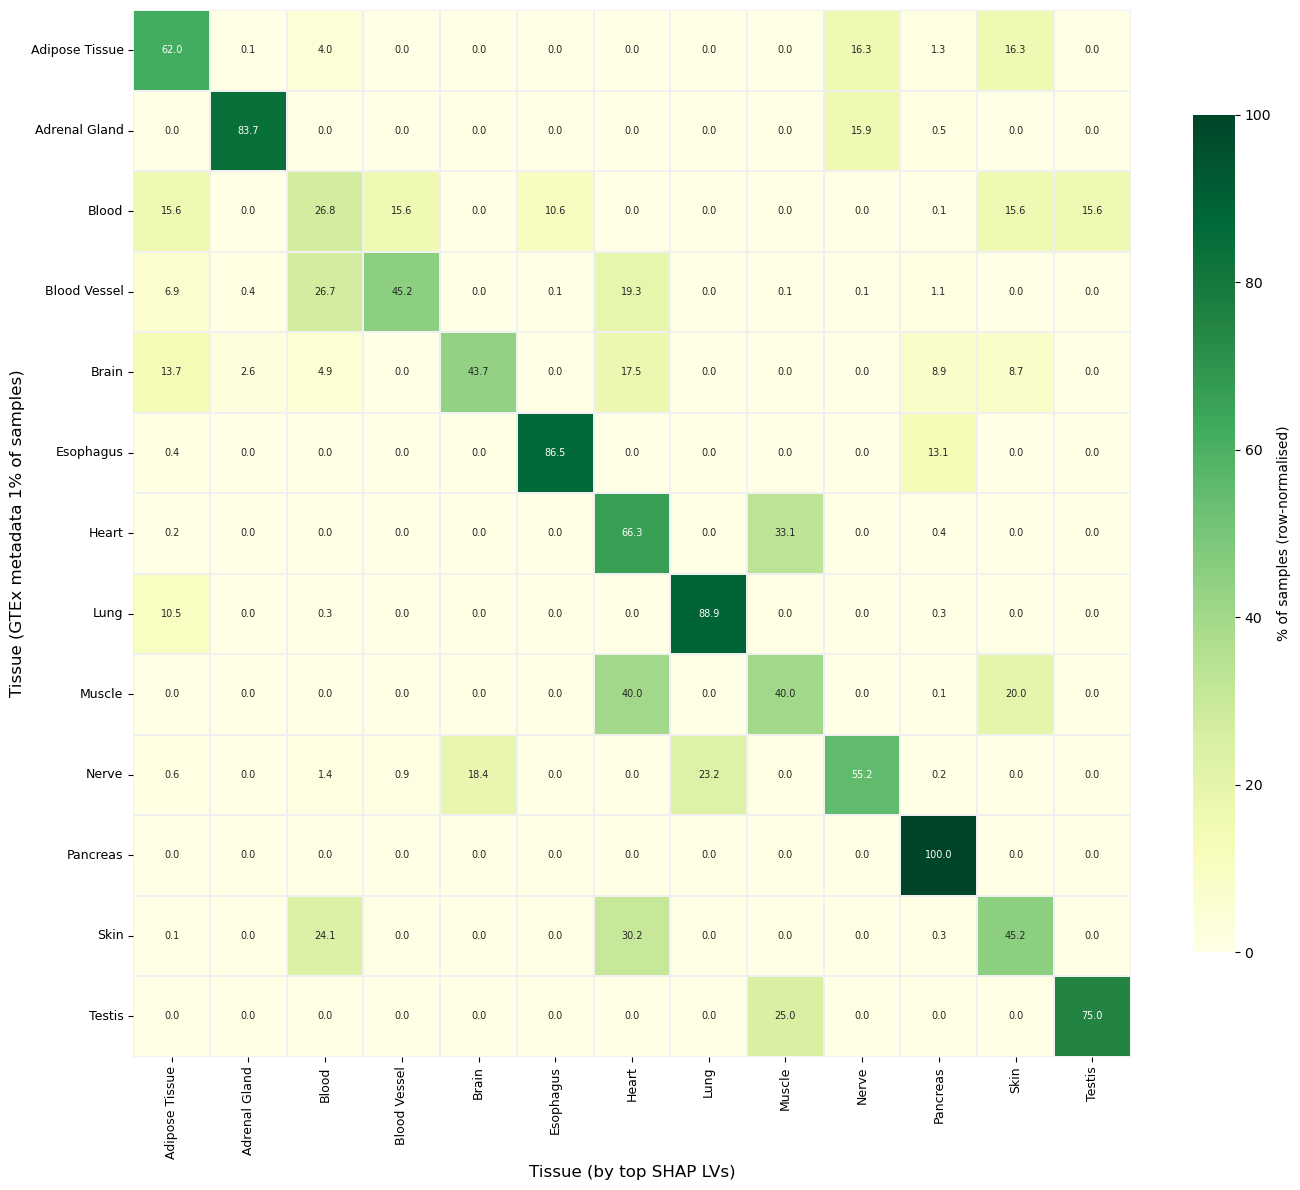

In [38]:
TOP_PCT = 0.01

n_top = max(1, int(len(lv_matrix) * TOP_PCT))
heatmap_matrix = np.zeros((len(tissues_ordered), len(tissues_ordered)))

for j, col_tissue in enumerate(tissues_ordered):
    top_lvs = top_per_tissue.get(col_tissue, [])
    pooled_tissues = []
    for lv in top_lvs:
        top_idx = lv_matrix[lv].nlargest(n_top).index
        pooled_tissues.extend(tissue_labels.loc[top_idx].tolist())
    tissue_counts = pd.Series(pooled_tissues).value_counts()
    for i, row_tissue in enumerate(tissues_ordered):
        heatmap_matrix[i, j] = tissue_counts.get(row_tissue, 0)

row_sums = heatmap_matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
heatmap_matrix_norm = heatmap_matrix / row_sums * 100

heatmap_df = pd.DataFrame(heatmap_matrix_norm, index=tissues_ordered, columns=tissues_ordered)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    heatmap_df,
    cmap='YlGn',
    vmin=0, vmax=100,
    linewidths=0.3,
    linecolor='#f0f0f0',
    ax=ax,
    annot=True,
    fmt='.1f',
    annot_kws={'size': 7},
    cbar_kws={'label': '% of samples (row-normalised)', 'shrink': 0.8}
)
ax.set_xlabel('Tissue (by top SHAP LVs)', fontsize=12)
ax.set_ylabel('Tissue (GTEx metadata 1% of samples)', fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

## Traits

In [39]:
phenoplier_filtered = (
    phenoplier.loc[phenoplier["fdr"] < 0.01, ["phenotype", "phenotype_desc", "lv", "fdr"]]
    .sort_values("fdr")
    .rename(columns={"phenotype": "pheno_id", "phenotype_desc": "phenotype", "lv": "LV"})
)

display(phenoplier_filtered.head())
phenoplier_filtered.shape

,pheno_id,phenotype,LV,fdr
278512,30240_raw,Reticulocyte percentage,LV52,1.764320e-31
637364,30190_raw,Monocyte percentage,LV250,8.767880e-31
1402860,30250_raw,Reticulocyte count,LV52,7.587580e-28
1014344,20002_1456,"Non-cancer illness code, self-reported: malabs...",LV324,1.316910e-27
1475372,30280_raw,Immature reticulocyte fraction,LV52,2.916400e-25


(1783, 4)

In [40]:
pheno_info_path = here('output/gtex/phenomexcan_simplified_phenotypes_info.tsv.gz')
if not pheno_info_path.exists():
    url = "https://zenodo.org/records/14941353/files/phenomexcan-phenotypes_info.tsv.gz?download=1"
    urllib.request.urlretrieve(url, pheno_info_path)
    print(f"downloaded to {pheno_info_path}")

pheno_info = pd.read_csv(pheno_info_path, sep='\t', compression='gzip', index_col='pheno_id')

pheno_info['n_eff'] = pheno_info['n'].combine_first(
    pheno_info['n_cases'] + pheno_info['n_controls']
)
desc_to_n = (
    pheno_info.dropna(subset=['n_eff'])
    .groupby('description')['n_eff']
    .max()
    .astype(int)
    .to_dict()
)

print(f"loaded {len(pheno_info)} phenotypes, {len(desc_to_n)} with n info")
pheno_info.head()

loaded 4091 phenotypes, 4034 with n info


/tmp/ipykernel_420846/802143465.py:9: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pheno_info['n_eff'] = pheno_info['n'].combine_first(


,full_code,short_code,description,unique_description,type,n,n_cases,n_controls,source,n_eff
pheno_id,,,,,,,,,,
0,100001_raw-Food_weight,100001_raw,Food weight,Food weight,continuous_raw,51453,NaN,NaN,UK Biobank,51453
1,100002_raw-Energy,100002_raw,Energy,Energy,continuous_raw,51453,NaN,NaN,UK Biobank,51453
2,100003_raw-Protein,100003_raw,Protein,Protein,continuous_raw,51453,NaN,NaN,UK Biobank,51453
3,100004_raw-Fat,100004_raw,Fat,Fat,continuous_raw,51453,NaN,NaN,UK Biobank,51453
4,100005_raw-Carbohydrate,100005_raw,Carbohydrate,Carbohydrate,continuous_raw,51453,NaN,NaN,UK Biobank,51453


/tmp/ipykernel_420846/577751218.py:149: RuntimeWarning: invalid value encountered in sqrt
  markersize=np.sqrt(n_to_size(v)),


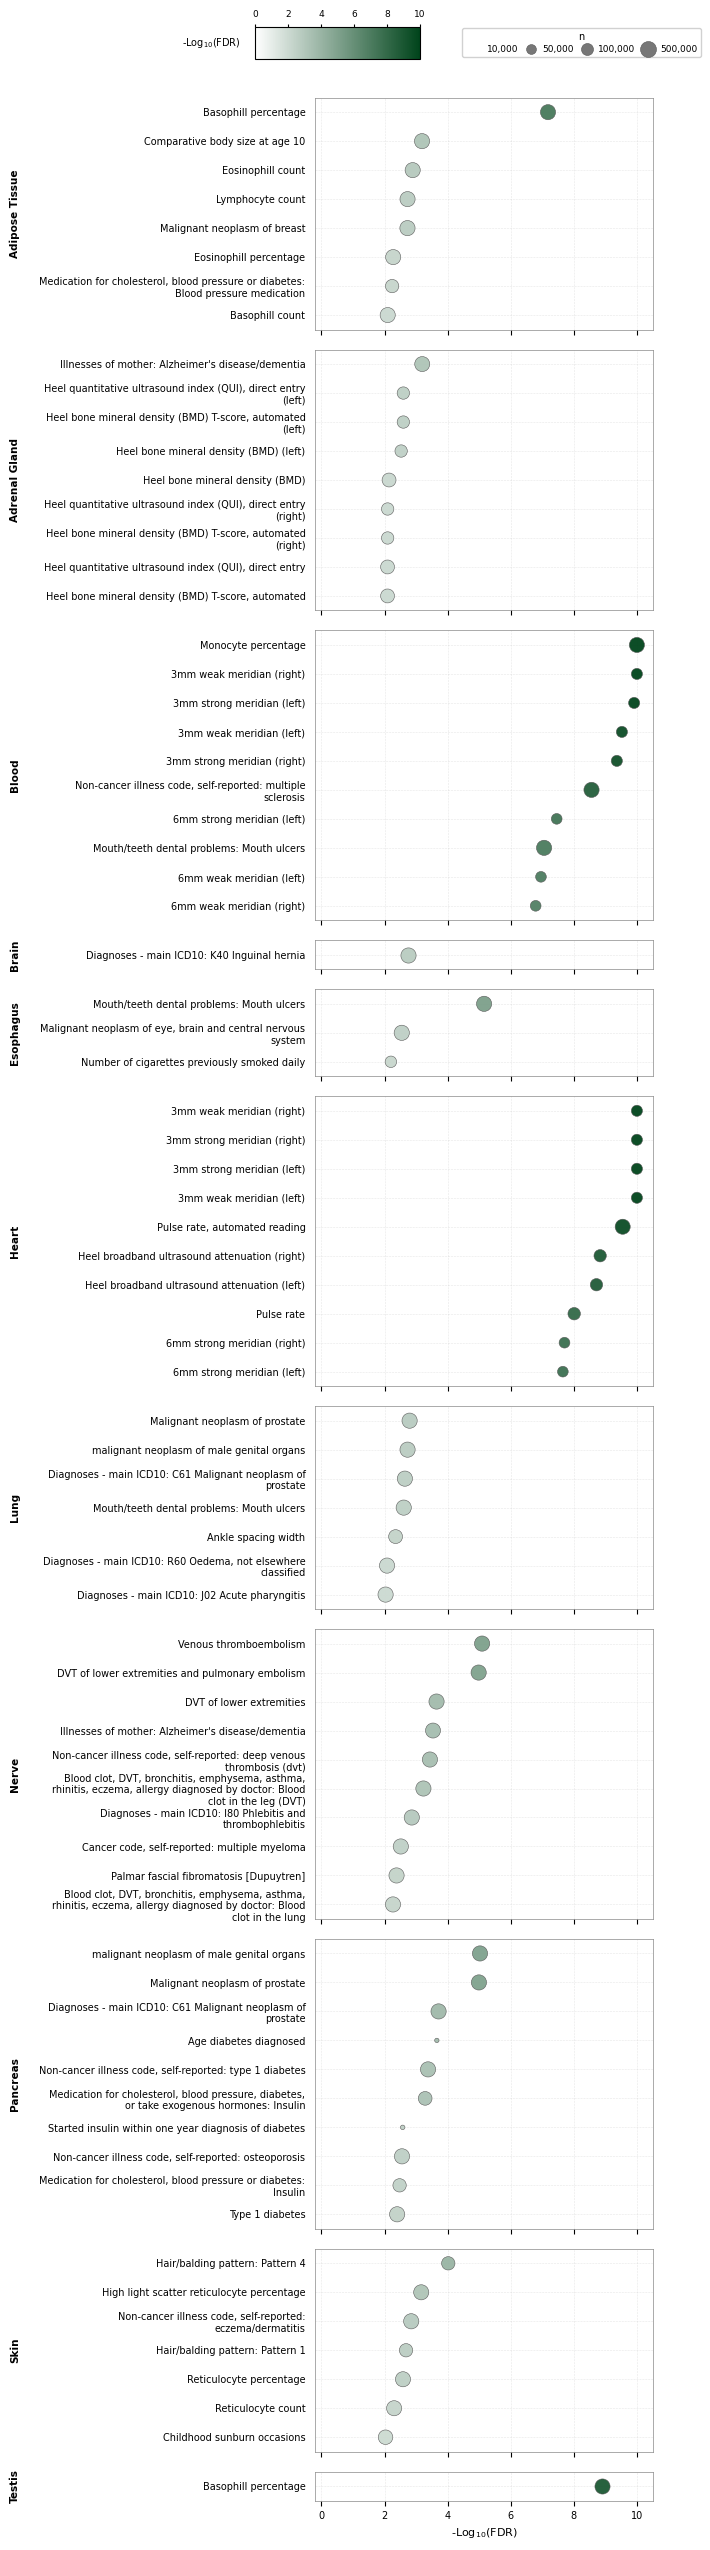

In [41]:
import textwrap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

MIN_N = 10000

trait_records = {}
seen_lvs = set()

for tissue in tissues_ordered:
    for lv in top_per_tissue.get(tissue, []):
        if lv in seen_lvs:
            continue
        matches = phenoplier_filtered[phenoplier_filtered['LV'] == lv].sort_values('fdr')
        found = False
        for _, mrow in matches.iterrows():
            n_val = desc_to_n.get(mrow['phenotype'])
            if n_val is None or n_val < MIN_N:
                continue
            found = True
            trait_records.setdefault(tissue, []).append({
                'trait': mrow['phenotype'],
                'n': n_val,
                'fdr': mrow['fdr'],
                'LV': lv,
            })
        if found:
            seen_lvs.add(lv)

for tissue in trait_records:
    seen_traits = {}
    for r in sorted(trait_records[tissue], key=lambda r: r['fdr']):
        if r['trait'] not in seen_traits:
            seen_traits[r['trait']] = r
    trait_records[tissue] = list(seen_traits.values())[:10]
    trait_records[tissue] = sorted(trait_records[tissue], key=lambda r: r['fdr'], reverse=True)

tissues_with_traits = [t for t in tissues_ordered if t in trait_records]

if not tissues_with_traits:
    print("no traits matched")
else:
    green_cmap = LinearSegmentedColormap.from_list('white_green', ['#ffffff', '#00441b'])

    all_fdr_t = [r['fdr'] for t in tissues_with_traits for r in trait_records[t]]
    neg_log_all = -np.log10(np.array(all_fdr_t).clip(min=1e-10))
    fdr_max = np.ceil(neg_log_all.max())
    x_max = fdr_max + 0.5
    norm = Normalize(vmin=0, vmax=fdr_max)

    all_n = [r['n'] for t in tissues_with_traits for r in trait_records[t]]
    log_n_min = np.log10(max(min(all_n), 1))
    log_n_max = np.log10(max(all_n))

    def n_to_size(n, s_min=10, s_max=120):
        log_n = np.log10(max(n, 1))
        return ((log_n - log_n_min) / (log_n_max - log_n_min + 1e-10)) * (s_max - s_min) + s_min

    height_ratios = [len(trait_records[t]) for t in tissues_with_traits]
    n = len(tissues_with_traits)
    total_rows = sum(height_ratios)

    fig = plt.figure(figsize=(7.5, total_rows * 0.32 + 1.8), facecolor='white')

    gs = gridspec.GridSpec(
        n, 1, figure=fig,
        height_ratios=height_ratios,
        hspace=0.10,
        top=0.97, bottom=0.05,
        left=0.5, right=0.95,
    )

    for idx, tissue in enumerate(tissues_with_traits):
        ax = fig.add_subplot(gs[idx])
        ax.set_facecolor('white')

        trecs = trait_records[tissue]
        traits    = [textwrap.fill(r['trait'], width=55) for r in trecs]
        ns        = np.array([r['n'] for r in trecs])
        fdrs      = np.array([r['fdr'] for r in trecs])
        neg_log_f = -np.log10(fdrs.clip(min=1e-10))
        sizes     = [n_to_size(nn) for nn in ns]
        y_pos     = np.arange(len(traits))

        ax.scatter(
            neg_log_f, y_pos,
            c=neg_log_f, s=sizes,
            cmap=green_cmap, norm=norm,
            edgecolors='#555555', linewidths=0.4, alpha=0.95, zorder=3,
        )

        ax.set_yticks(y_pos)
        ax.set_yticklabels(traits, fontsize=7, ha='right')
        ax.set_xlim(-0.2, x_max)
        ax.set_ylim(-0.5, len(traits) - 0.5)

        fig.text(
            0.10, (gs[idx].get_position(fig).y0 + gs[idx].get_position(fig).y1) / 2,
            tissue,
            fontsize=7.5, fontweight='bold',
            va='center', ha='center',
            rotation=90,
        )

        ax.grid(True, axis='x', linestyle='--', linewidth=0.4, alpha=0.35, color='#bbbbbb', zorder=0)
        ax.grid(True, axis='y', linestyle='--', linewidth=0.4, alpha=0.35, color='#bbbbbb', zorder=0)
        ax.set_axisbelow(True)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)
            spine.set_color('#888888')

        if idx == n - 1:
            ax.set_xlabel('-Log$_{10}$(FDR)', fontsize=8)
        else:
            ax.tick_params(labelbottom=False)
        ax.tick_params(left=False, which='both', labelsize=7)

    legend_y = 0.985
    cbar_h = 0.012

    fig.text(
        0.40, legend_y + cbar_h / 2,
        '-Log$_{10}$(FDR)',
        fontsize=7, va='center', ha='right',
    )

    cbar_ax = fig.add_axes([0.42, legend_y, 0.22, cbar_h])
    sm = ScalarMappable(cmap=green_cmap, norm=norm)
    sm.set_array([])
    cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    tick_step = max(1, int(fdr_max // 5))
    cb.set_ticks(np.arange(0, fdr_max + 1, tick_step))
    cb.ax.tick_params(labelsize=6.5, top=True, bottom=False,
                      labeltop=True, labelbottom=False, length=2.5)

    legend_ns = [v for v in [10000, 50000, 100000, 500000]
                 if min(all_n) * 0.5 <= v <= max(all_n) * 2]
    if not legend_ns:
        legend_ns = [min(all_n), max(all_n)]
    legend_handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='#777777',
               markersize=np.sqrt(n_to_size(v)),
               label=f'{v:,}',
               markeredgecolor='#555555', markeredgewidth=0.4)
        for v in legend_ns
    ]
    fig.legend(
        handles=legend_handles,
        title='n',
        bbox_to_anchor=(0.69, legend_y + cbar_h / 2),
        loc='center left',
        fontsize=6.5, title_fontsize=7,
        frameon=True, framealpha=0.9,
        edgecolor='#cccccc',
        ncol=len(legend_ns),
        labelspacing=0.3,
        handletextpad=0.3,
        borderpad=0.4,
        columnspacing=0.4,
    )

    plt.show()

## BP

In [46]:
gtex_GO_BP_summary_sub = gtex_GO_BP_summary[(gtex_GO_BP_summary['AUC'] > 0.6) & (gtex_GO_BP_summary['FDR'] < 0.1)]

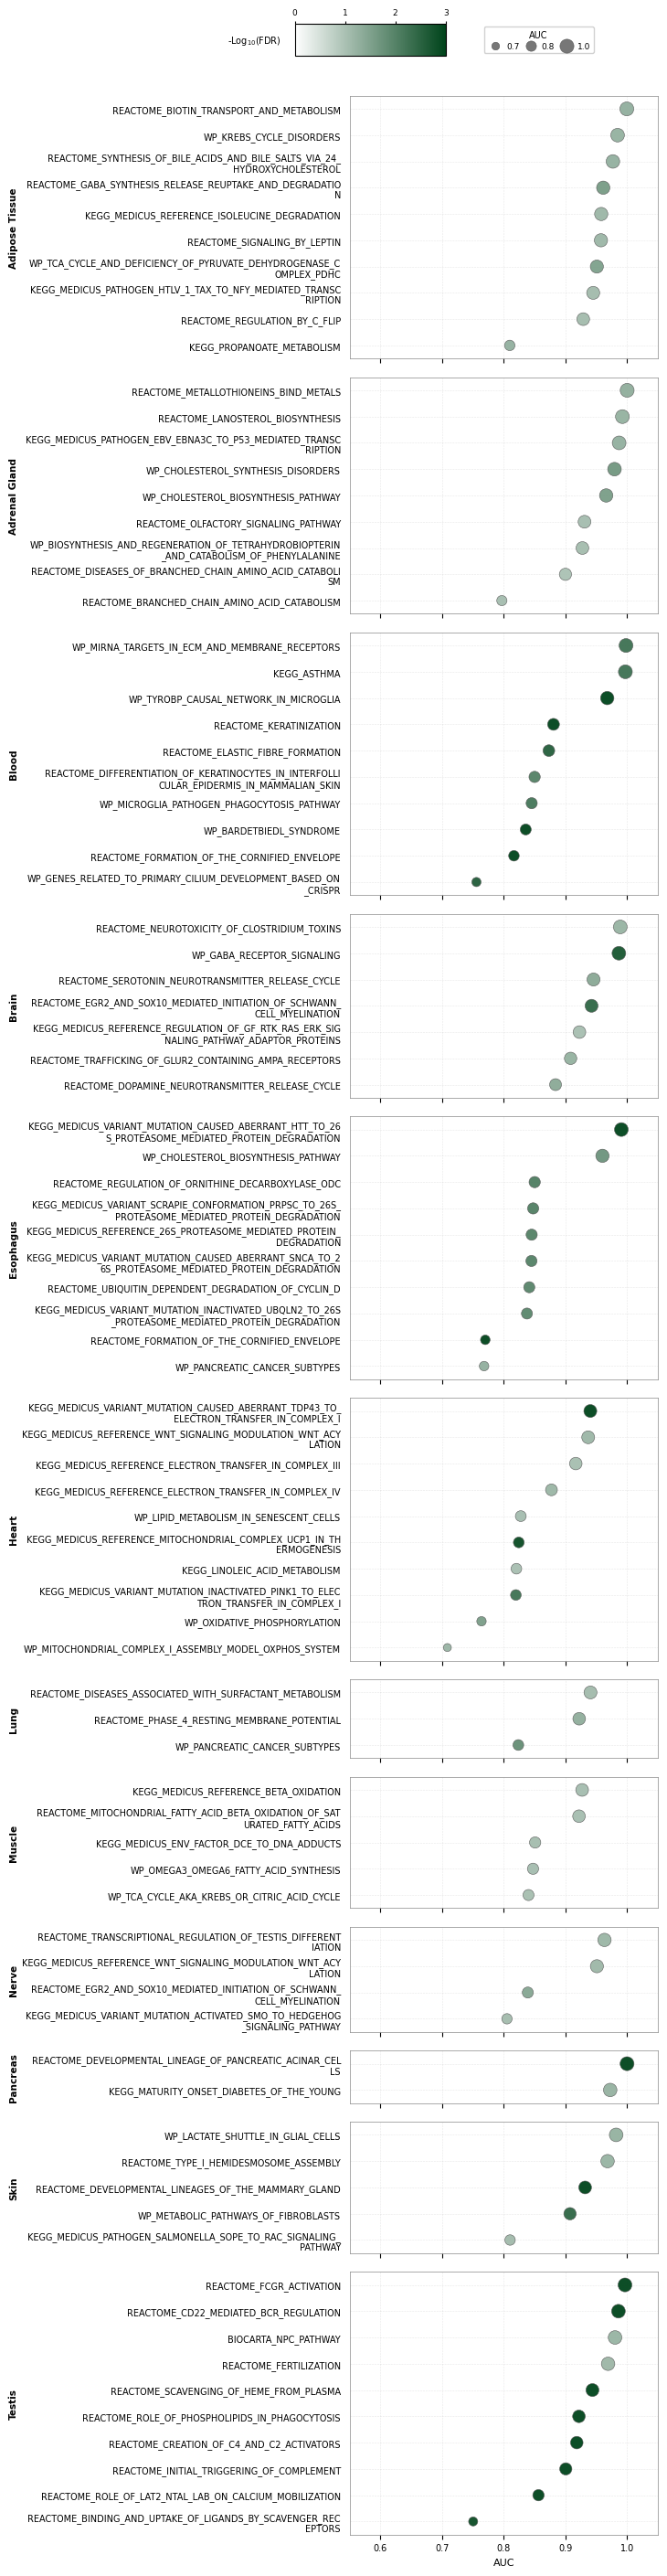

In [47]:
import textwrap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

records = {}
seen_lvs = set()

for tissue in tissues_ordered:
    for lv in top_per_tissue.get(tissue, []):
        if lv in seen_lvs:
            continue
        seen_lvs.add(lv)
        go_hits = gtex_GO_BP_summary_sub[
            gtex_GO_BP_summary_sub['LV'] == lv
        ].sort_values('FDR')
        for _, grow in go_hits.iterrows():
            records.setdefault(tissue, []).append({
                'pathway_short': grow['pathway'],
                'AUC': grow['AUC'],
                'FDR': grow['FDR'],
                'LV': lv,
            })

for tissue in records:
    seen_bp = {}
    for r in sorted(records[tissue], key=lambda r: r['FDR']):
        if r['pathway_short'] not in seen_bp:
            seen_bp[r['pathway_short']] = r
    records[tissue] = list(seen_bp.values())[:10]
    records[tissue] = sorted(records[tissue], key=lambda r: r['AUC'], reverse=False)

tissues_with_data = [t for t in tissues_ordered if t in records]
height_ratios = [len(records[t]) for t in tissues_with_data]
n = len(tissues_with_data)
total_rows = sum(height_ratios)

green_cmap = LinearSegmentedColormap.from_list('white_green', ['#ffffff', '#00441b'])
norm = Normalize(vmin=0, vmax=3)

auc_min, auc_max = 0.6, 1.0


def auc_to_size(auc, s_min=10, s_max=120):
    return ((auc - auc_min) / (auc_max - auc_min)) * (s_max - s_min) + s_min


fig = plt.figure(figsize=(7.5, total_rows * 0.32 + 1.8), facecolor='white')

gs = gridspec.GridSpec(
    n, 1, figure=fig,
    height_ratios=height_ratios,
    hspace=0.10,
    top=0.97, bottom=0.05,
    left=0.5, right=0.95,
)

for idx, tissue in enumerate(tissues_with_data):
    ax = fig.add_subplot(gs[idx])
    ax.set_facecolor('white')

    tissue_records = records[tissue]
    pathways  = [textwrap.fill(r['pathway_short'], width=55) for r in tissue_records]
    aucs      = np.array([r['AUC'] for r in tissue_records])
    fdrs      = np.array([r['FDR'] for r in tissue_records])
    neg_log_f = np.clip(-np.log10(fdrs.clip(min=1e-10)), 0, 3)
    sizes     = [auc_to_size(a) for a in aucs]
    y_pos     = np.arange(len(pathways))

    ax.scatter(
        aucs, y_pos,
        c=neg_log_f, s=sizes,
        cmap=green_cmap, norm=norm,
        edgecolors='#555555', linewidths=0.4, alpha=0.95, zorder=3,
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(pathways, fontsize=7, ha='right')
    ax.set_xlim(0.55, 1.05)
    ax.set_ylim(-0.5, len(pathways) - 0.5)

    # tissue label x-position: lower value = more space between tissue and BP
    fig.text(
        0.01, (gs[idx].get_position(fig).y0 + gs[idx].get_position(fig).y1) / 2,
        tissue,
        fontsize=7.5, fontweight='bold',
        va='center', ha='center',
        rotation=90,
    )

    ax.grid(True, axis='x', linestyle='--', linewidth=0.4, alpha=0.35, color='#bbbbbb', zorder=0)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.4, alpha=0.35, color='#bbbbbb', zorder=0)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color('#888888')

    if idx == n - 1:
        ax.set_xlabel('AUC', fontsize=8)
    else:
        ax.tick_params(labelbottom=False)
    ax.tick_params(left=False, which='both', labelsize=7)

legend_y = 0.985
cbar_h = 0.012

fig.text(
    0.40, legend_y + cbar_h / 2,
    '-Log$_{10}$(FDR)',
    fontsize=7, va='center', ha='right',
)

cbar_ax = fig.add_axes([0.42, legend_y, 0.22, cbar_h])
sm = ScalarMappable(cmap=green_cmap, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cb.set_ticks([0.0, 1.0, 2.0, 3.0])
cb.ax.tick_params(labelsize=6.5, top=True, bottom=False,
                  labeltop=True, labelbottom=False, length=2.5)

legend_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#777777',
           markersize=np.sqrt(auc_to_size(v)),
           label=f'{v:.1f}',
           markeredgecolor='#555555', markeredgewidth=0.4)
    for v in [0.7, 0.8, 1.0]
]
fig.legend(
    handles=legend_handles,
    title='AUC',
    bbox_to_anchor=(0.69, legend_y + cbar_h / 2),
    loc='center left',
    fontsize=6.5, title_fontsize=7,
    frameon=True, framealpha=0.9,
    edgecolor='#cccccc',
    ncol=3,
    labelspacing=0.3,
    handletextpad=0.3,
    borderpad=0.4,
    columnspacing=0.4,
)

plt.show()

In [48]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

rows = []
for tissue in tissues_with_data:
    for r in records[tissue]:
        rows.append({
            'tissue': tissue,
            'pathway': r['pathway_short'],
            'AUC': r['AUC'],
            'FDR': r['FDR'],
            'LV': r['LV'],
        })

df_pathways = pd.DataFrame(rows)
df_pathways['tissue'] = pd.Categorical(df_pathways['tissue'], categories=tissues_with_data, ordered=True)
df_pathways = df_pathways.sort_values(['tissue', 'FDR'], ascending=[True, True]).reset_index(drop=True)
df_pathways

,tissue,pathway,AUC,FDR,LV
0,Adipose Tissue,REACTOME_GABA_SYNTHESIS_RELEASE_REUPTAKE_AND_D...,0.961183,2.494503e-02,LV230
1,Adipose Tissue,WP_TCA_CYCLE_AND_DEFICIENCY_OF_PYRUVATE_DEHYDR...,0.950819,2.936240e-02,LV333
2,Adipose Tissue,REACTOME_BIOTIN_TRANSPORT_AND_METABOLISM,0.999419,5.086575e-02,LV333
3,Adipose Tissue,KEGG_PROPANOATE_METABOLISM,0.809592,5.199205e-02,LV333
4,Adipose Tissue,REACTOME_SYNTHESIS_OF_BILE_ACIDS_AND_BILE_SALT...,0.976858,5.199205e-02,LV151
5,Adipose Tissue,WP_KREBS_CYCLE_DISORDERS,0.984432,5.428415e-02,LV333
6,Adipose Tissue,KEGG_MEDICUS_REFERENCE_ISOLEUCINE_DEGRADATION,0.957921,6.569599e-02,LV333
7,Adipose Tissue,REACTOME_SIGNALING_BY_LEPTIN,0.957470,6.571204e-02,LV319
8,Adipose Tissue,KEGG_MEDICUS_PATHOGEN_HTLV_1_TAX_TO_NFY_MEDIAT...,0.944910,7.902593e-02,LV301
9,Adipose Tissue,REACTOME_REGULATION_BY_C_FLIP,0.928721,8.045949e-02,LV386


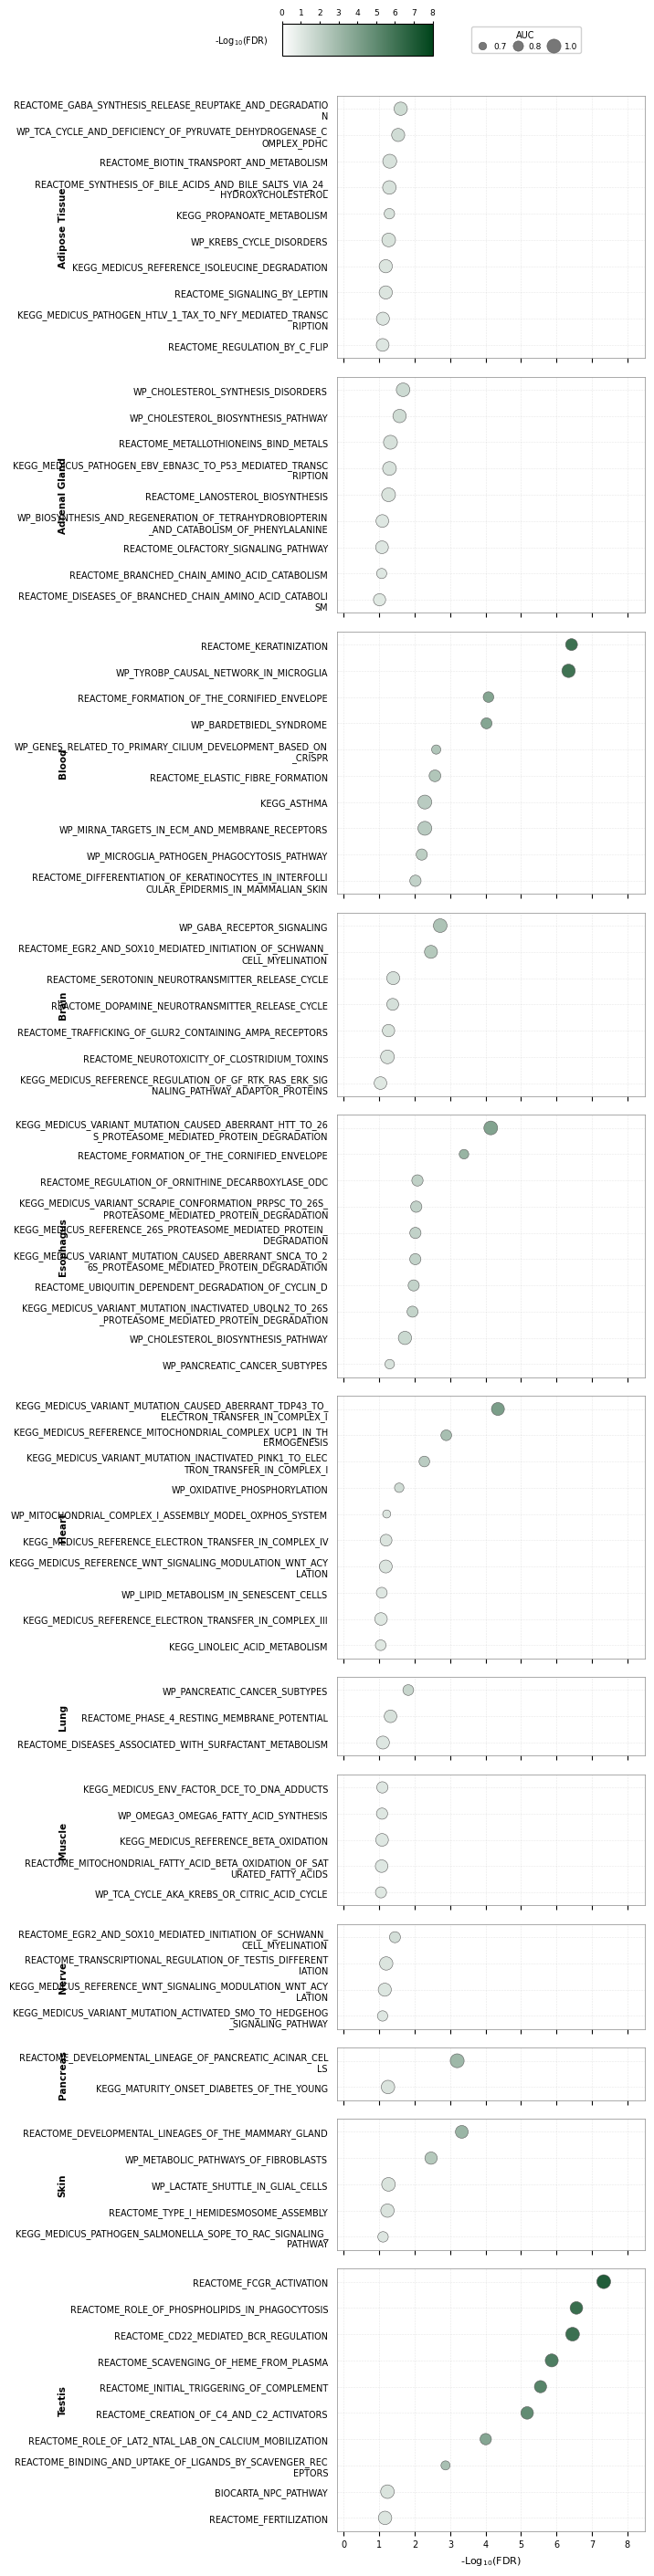

In [49]:
import textwrap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

records = {}
seen_lvs = set()

for tissue in tissues_ordered:
    for lv in top_per_tissue.get(tissue, []):
        if lv in seen_lvs:
            continue
        seen_lvs.add(lv)
        go_hits = gtex_GO_BP_summary_sub[
            gtex_GO_BP_summary_sub['LV'] == lv
        ].sort_values('FDR')
        for _, grow in go_hits.iterrows():
            records.setdefault(tissue, []).append({
                'pathway_short': grow['pathway'],
                'AUC': grow['AUC'],
                'FDR': grow['FDR'],
                'LV': lv,
            })

for tissue in records:
    seen_bp = {}
    for r in sorted(records[tissue], key=lambda r: r['FDR']):
        if r['pathway_short'] not in seen_bp:
            seen_bp[r['pathway_short']] = r
    records[tissue] = list(seen_bp.values())[:10]
    records[tissue] = sorted(records[tissue], key=lambda r: r['FDR'], reverse=True)

tissues_with_data = [t for t in tissues_ordered if t in records]
height_ratios = [len(records[t]) for t in tissues_with_data]
n = len(tissues_with_data)
total_rows = sum(height_ratios)

green_cmap = LinearSegmentedColormap.from_list('white_green', ['#ffffff', '#00441b'])

all_fdr = [r['FDR'] for t in tissues_with_data for r in records[t]]
neg_log_all = -np.log10(np.array(all_fdr).clip(min=1e-10))
fdr_max = np.ceil(neg_log_all.max())
x_max = fdr_max + 0.5
norm = Normalize(vmin=0, vmax=fdr_max)

auc_min, auc_max = 0.6, 1.0


def auc_to_size(auc, s_min=10, s_max=120):
    return ((auc - auc_min) / (auc_max - auc_min)) * (s_max - s_min) + s_min


fig = plt.figure(figsize=(7.5, total_rows * 0.32 + 1.8), facecolor='white')

gs = gridspec.GridSpec(
    n, 1, figure=fig,
    height_ratios=height_ratios,
    hspace=0.10,
    top=0.97, bottom=0.05,
    left=0.5, right=0.95,
)

for idx, tissue in enumerate(tissues_with_data):
    ax = fig.add_subplot(gs[idx])
    ax.set_facecolor('white')

    tissue_records = records[tissue]
    pathways  = [textwrap.fill(r['pathway_short'], width=55) for r in tissue_records]
    aucs      = np.array([r['AUC'] for r in tissue_records])
    fdrs      = np.array([r['FDR'] for r in tissue_records])
    neg_log_f = -np.log10(fdrs.clip(min=1e-10))
    sizes     = [auc_to_size(a) for a in aucs]
    y_pos     = np.arange(len(pathways))

    ax.scatter(
        neg_log_f, y_pos,
        c=neg_log_f, s=sizes,
        cmap=green_cmap, norm=norm,
        edgecolors='#555555', linewidths=0.4, alpha=0.95, zorder=3,
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(pathways, fontsize=7, ha='right')
    ax.set_xlim(-0.2, x_max)
    ax.set_ylim(-0.5, len(pathways) - 0.5)

    fig.text(
        0.10, (gs[idx].get_position(fig).y0 + gs[idx].get_position(fig).y1) / 2,
        tissue,
        fontsize=7.5, fontweight='bold',
        va='center', ha='center',
        rotation=90,
    )

    ax.grid(True, axis='x', linestyle='--', linewidth=0.4, alpha=0.35, color='#bbbbbb', zorder=0)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.4, alpha=0.35, color='#bbbbbb', zorder=0)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color('#888888')

    if idx == n - 1:
        ax.set_xlabel('-Log$_{10}$(FDR)', fontsize=8)
    else:
        ax.tick_params(labelbottom=False)
    ax.tick_params(left=False, which='both', labelsize=7)

legend_y = 0.985
cbar_h = 0.012

fig.text(
    0.40, legend_y + cbar_h / 2,
    '-Log$_{10}$(FDR)',
    fontsize=7, va='center', ha='right',
)

cbar_ax = fig.add_axes([0.42, legend_y, 0.22, cbar_h])
sm = ScalarMappable(cmap=green_cmap, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
tick_step = max(1, int(fdr_max // 5))
cb.set_ticks(np.arange(0, fdr_max + 1, tick_step))
cb.ax.tick_params(labelsize=6.5, top=True, bottom=False,
                  labeltop=True, labelbottom=False, length=2.5)

legend_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#777777',
           markersize=np.sqrt(auc_to_size(v)),
           label=f'{v:.1f}',
           markeredgecolor='#555555', markeredgewidth=0.4)
    for v in [0.7, 0.8, 1.0]
]
fig.legend(
    handles=legend_handles,
    title='AUC',
    bbox_to_anchor=(0.69, legend_y + cbar_h / 2),
    loc='center left',
    fontsize=6.5, title_fontsize=7,
    frameon=True, framealpha=0.9,
    edgecolor='#cccccc',
    ncol=3,
    labelspacing=0.3,
    handletextpad=0.3,
    borderpad=0.4,
    columnspacing=0.4,
)

plt.show()